<a href="https://colab.research.google.com/github/FeshDragocei/For-intelegent-practice/blob/main/pr_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Данные загружены и записаны в dataframe!
(195, 43)


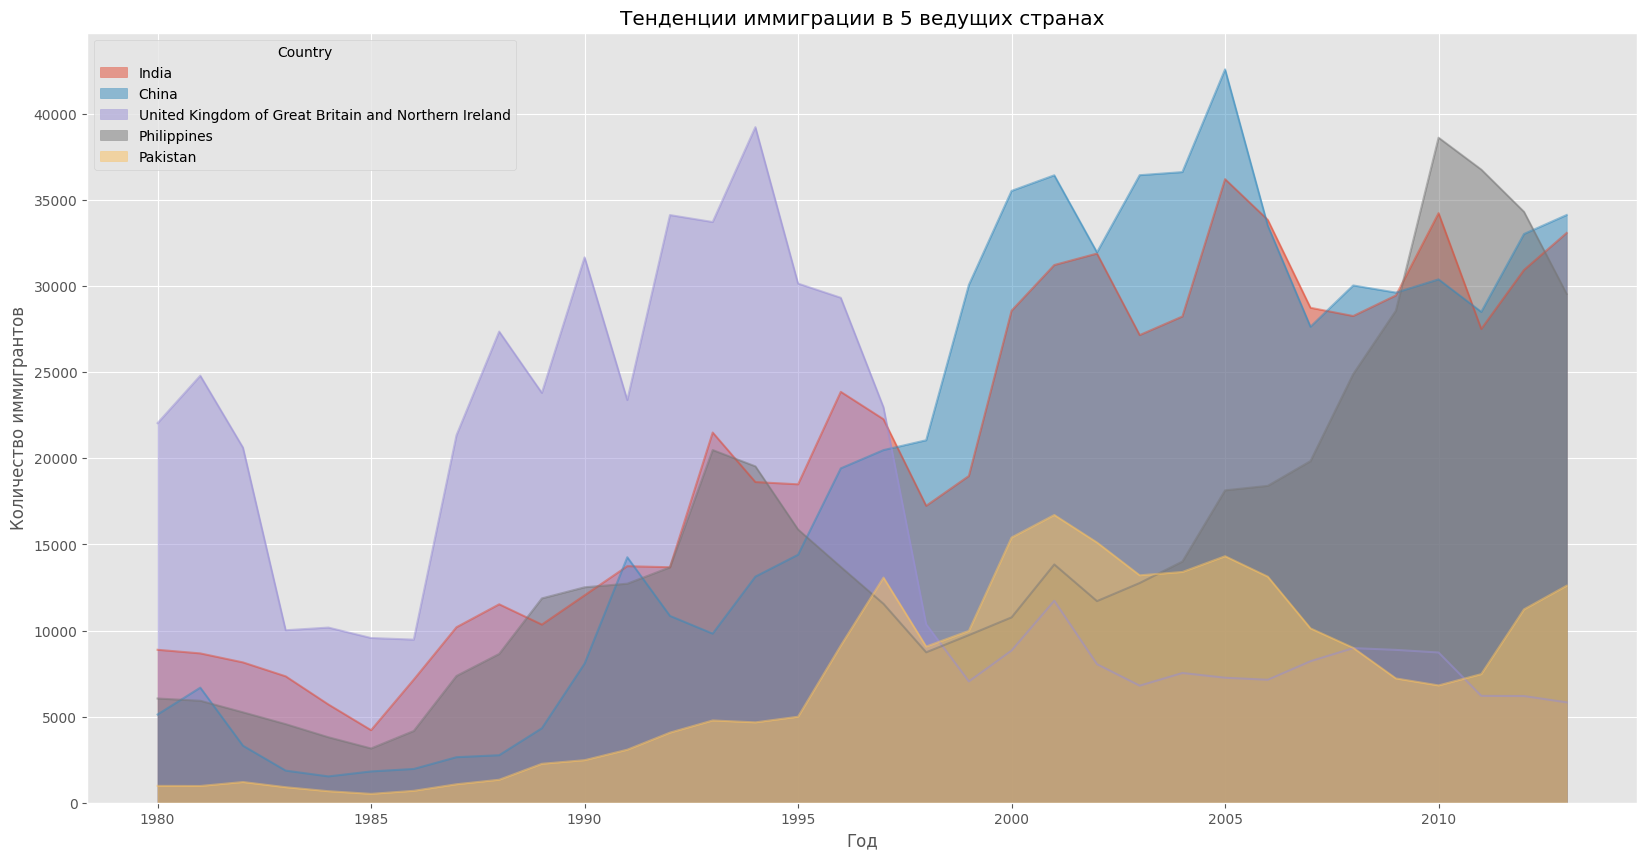

[178  11   1   2   0   0   0   0   1   2]
[    0.   3412.9  6825.8 10238.7 13651.6 17064.5 20477.4 23890.3 27303.2
 30716.1 34129. ]


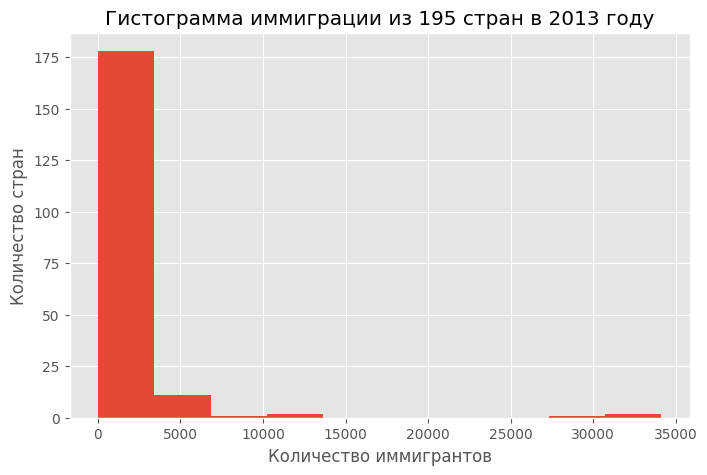

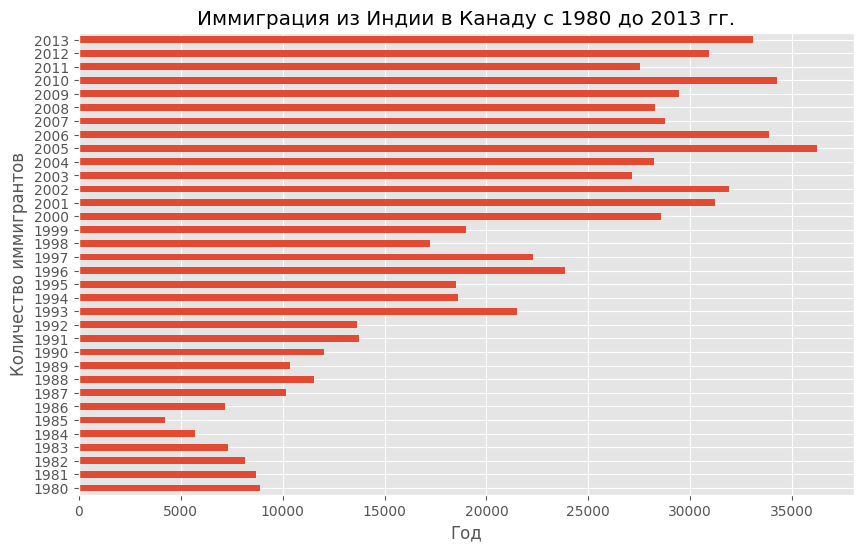

In [ ]:
import numpy as np
import pandas as pd

df_can = pd.read_excel('https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DV0101EN/labs/Data_Files/Canada.xlsx',
          sheet_name='Canada by Citizenship',
          skiprows=range(20),
          skipfooter=2)
print('Данные загружены и записаны в dataframe!')

df_can.head()
print(df_can.shape)

df_can.drop(['AREA', 'REG', 'DEV', 'Type', 'Coverage'], axis=1, inplace=True)
df_can.head()

df_can.rename(columns={'OdName':'Country', 'AreaName':'Continent','RegName':'Region'}, inplace=True)
df_can.head()

all(isinstance(column, str) for column in df_can.columns)

df_can.columns = list(map(str, df_can.columns))
all(isinstance(column, str) for column in df_can.columns)

df_can.set_index('Country', inplace=True)
df_can.head()

# Выбираем только столбцы с годами для суммирования
years = list(map(str, range(1980, 2014)))
df_can['Total'] = df_can[years].sum(axis=1)
df_can.head()

years = list(map(str, range(1980, 2014)))
df_can.sort_values(['Total'], ascending=False, axis=0, inplace=True)
df_top5 = df_can.head()
# Транспонирование таблицы
df_top5 = df_top5[years].transpose()
df_top5.head()

%matplotlib inline

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use('ggplot') # опционально: задаем стиль ggplot

# Для построения графика изменяем тип индексов строк (года)
# на integer
df_top5.index = df_top5.index.map(int)

# Построение графика типа ‘area’ встроенной
# в pandas суб-библиотекой matplotlib
df_top5.plot(kind='area',
             stacked=False,
             figsize=(20, 10), # размер области построения графика
             )

#Задаем наименование графика
plt.title('Тенденции иммиграции в 5 ведущих странах')
#Задаем наименование оси Y
plt.ylabel('Количество иммигрантов')
#Задаем наименование оси X
plt.xlabel('Год')
# Выводим график со всеми параметрами на экран
plt.show()

df_can['2013'].head()

count, bin_edges = np.histogram(df_can['2013'])

print(count) # подсчет частоты появления данных
print(bin_edges) # количество столбцов, по умолчанию – 10

df_can['2013'].plot(kind='hist', figsize=(8, 5))
plt.title('Гистограмма иммиграции из 195 стран в 2013 году') # добавление названия
plt.ylabel('Количество стран') # добавление наименования оси у
plt.xlabel('Количество иммигрантов') # наименование оси х
plt.show()

df_india = df_can.loc['India', years]
df_india.head()

df_india.plot(kind='barh', figsize=(10, 6))
plt.xlabel('Год') # add to x-label to the plot
plt.ylabel('Количество иммигрантов') # add y-label to the plot
plt.title('Иммиграция из Индии в Канаду с 1980 до 2013 гг.') # add title to the plot
plt.show()